# Week 6: Decision Trees and Random Forests


**Project:** Marketing Conversion Propensity

This notebook applies Decision Tree and Random Forest classification models to predict marketing conversion propensity. The goal is to compare a single tree model with an ensemble model and evaluate which approach better predicts high versus low conversion outcomes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("marketing_and_product_performance.csv")

df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
)

df.head()

,campaign_id,product_id,budget,clicks,conversions,revenue_generated,roi,customer_id,subscription_tier,subscription_length,flash_sale_id,discount_level,units_sold,bundle_id,bundle_price,customer_satisfaction_post_refund,common_keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [3]:
print(df.info())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   campaign_id                        10000 non-null  str    
 1   product_id                         10000 non-null  str    
 2   budget                             10000 non-null  float64
 3   clicks                             10000 non-null  int64  
 4   conversions                        10000 non-null  int64  
 5   revenue_generated                  10000 non-null  float64
 6   roi                                10000 non-null  float64
 7   customer_id                        10000 non-null  str    
 8   subscription_tier                  10000 non-null  str    
 9   subscription_length                10000 non-null  int64  
 10  flash_sale_id                      10000 non-null  str    
 11  discount_level                     10000 non-null  int64  
 12  un

,budget,clicks,conversions,revenue_generated,roi,subscription_length,discount_level,units_sold,bundle_price,customer_satisfaction_post_refund
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25263.607524,2481.903600,498.978700,50038.627579,2.756365,18.016500,39.421000,100.689600,275.198346,2.500900
std,14350.085927,1435.973623,289.479495,28545.702337,1.296901,10.149666,17.212925,57.074015,129.218710,1.113249
min,500.440000,10.000000,1.000000,1002.080000,0.500000,1.000000,10.000000,1.000000,50.010000,1.000000
25%,12789.190000,1225.750000,247.000000,25264.255000,1.630000,9.000000,24.000000,52.000000,165.717500,2.000000
50%,25030.170000,2451.000000,499.000000,49513.815000,2.750000,18.000000,39.000000,101.000000,272.555000,2.000000
75%,37921.725000,3723.000000,751.000000,74507.157500,3.890000,27.000000,54.000000,150.000000,387.322500,3.000000
max,49999.630000,4999.000000,999.000000,99999.470000,5.000000,35.000000,69.000000,199.000000,499.970000,4.000000


In [4]:
print(df.columns.tolist())

['campaign_id', 'product_id', 'budget', 'clicks', 'conversions', 'revenue_generated', 'roi', 'customer_id', 'subscription_tier', 'subscription_length', 'flash_sale_id', 'discount_level', 'units_sold', 'bundle_id', 'bundle_price', 'customer_satisfaction_post_refund', 'common_keywords']


In [5]:
## Create the Target Variable
df["high_conversion"] = (
    df["conversions"] > df["conversions"].median()
).astype(int)

df["high_conversion"].value_counts()

high_conversion
0    5001
1    4999
Name: count, dtype: int64

In [6]:
## Select Predictor Variables
features = [
    "budget",
    "clicks",
    "revenue_generated",
    "roi",
    "subscription_length",
    "discount_level",
    "units_sold",
    "bundle_price",
    "customer_satisfaction_post_refund"
]

X = df[features]
y = df["high_conversion"]

X = X.fillna(X.mean())

In [7]:
## Split the Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
## Decision Tree Model
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))

print(classification_report(y_test, y_pred_tree))

Decision Tree Results
Accuracy: 0.461
Precision: 0.45050761421319796
Recall: 0.355
F1 Score: 0.3970917225950783
              precision    recall  f1-score   support

           0       0.47      0.57      0.51      1000
           1       0.45      0.35      0.40      1000

    accuracy                           0.46      2000
   macro avg       0.46      0.46      0.45      2000
weighted avg       0.46      0.46      0.45      2000



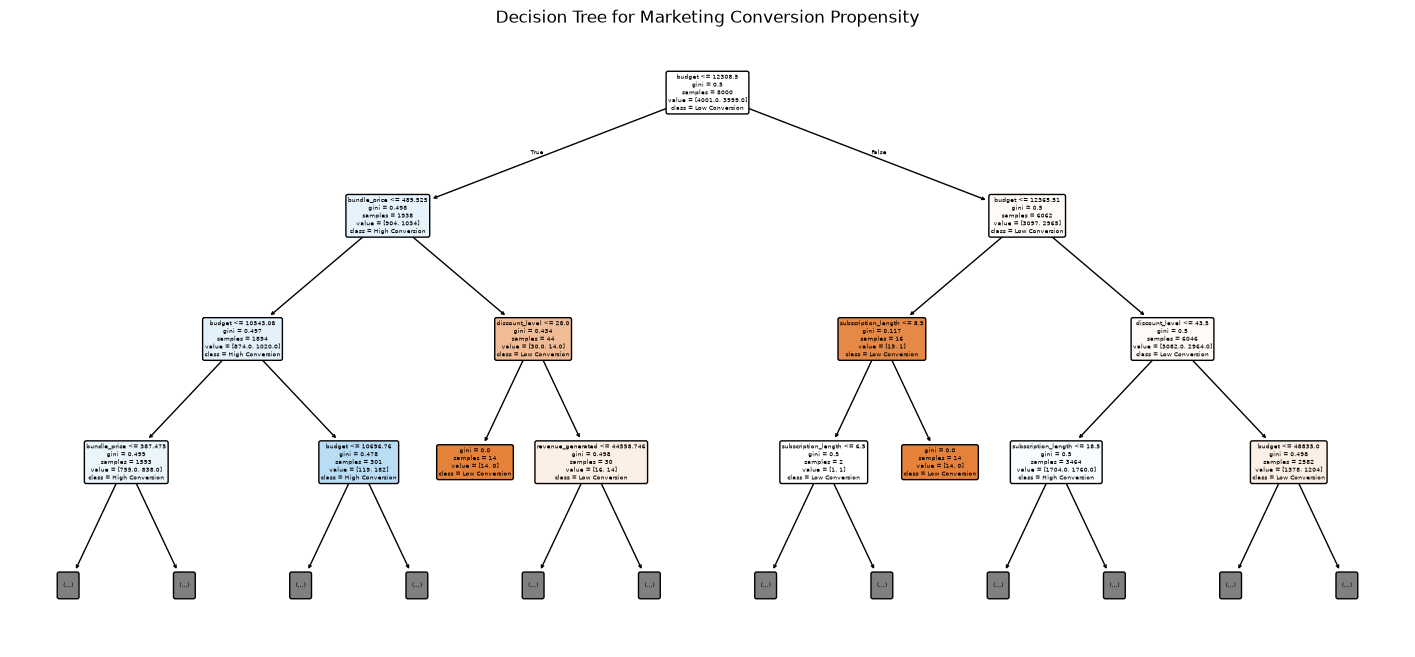

In [9]:
## Decision Tree Visualization
plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=features,
    class_names=["Low Conversion", "High Conversion"],
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title("Decision Tree for Marketing Conversion Propensity")
plt.show()

In [10]:
## Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.4875
Precision: 0.48743718592964824
Recall: 0.485
F1 Score: 0.48621553884711777
              precision    recall  f1-score   support

           0       0.49      0.49      0.49      1000
           1       0.49      0.48      0.49      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



In [11]:
## Random Forest Cross-Validation
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Cross-Validation F1 Scores:", cv_scores)
print("Mean Cross-Validation F1:", cv_scores.mean())

Cross-Validation F1 Scores: [0.45788337 0.47893333 0.47774936 0.48911917 0.48146214]
Mean Cross-Validation F1: 0.4770294750508441


In [12]:
## Hyperparameter Tuning for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Cross-Validation F1:", grid_rf.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-Validation F1: 0.5174273447699327


In [13]:
## Evaluate the Best Random Forest Model
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Best Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall:", recall_score(y_test, y_pred_best_rf))
print("F1 Score:", f1_score(y_test, y_pred_best_rf))

print(classification_report(y_test, y_pred_best_rf))

Best Random Forest Results
Accuracy: 0.487
Precision: 0.4871031746031746
Recall: 0.491
F1 Score: 0.48904382470119523
              precision    recall  f1-score   support

           0       0.49      0.48      0.48      1000
           1       0.49      0.49      0.49      1000

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



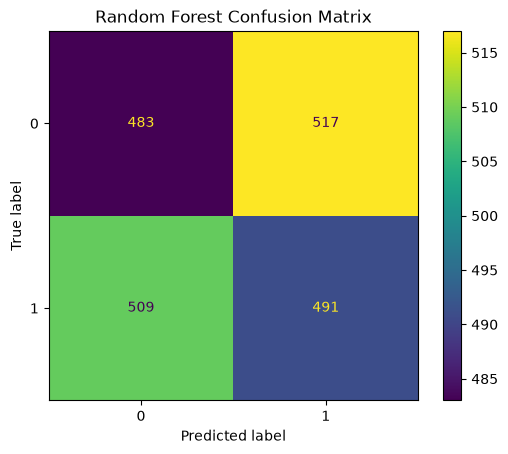

In [14]:
## Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [15]:
## Feature Importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
7,bundle_price,0.167488
1,clicks,0.147525
0,budget,0.137913
2,revenue_generated,0.121414
3,roi,0.111022
6,units_sold,0.103740
5,discount_level,0.099688
4,subscription_length,0.094997
8,customer_satisfaction_post_refund,0.016213


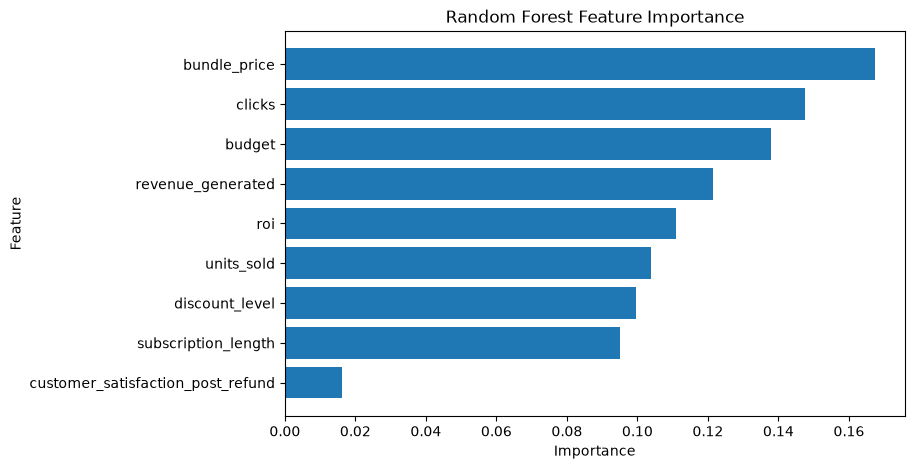

In [16]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [17]:
## Model Comparison
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Tuned Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_best_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_best_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_best_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_best_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.4610,0.450508,0.355,0.397092
1,Random Forest,0.4875,0.487437,0.485,0.486216
2,Tuned Random Forest,0.4870,0.487103,0.491,0.489044


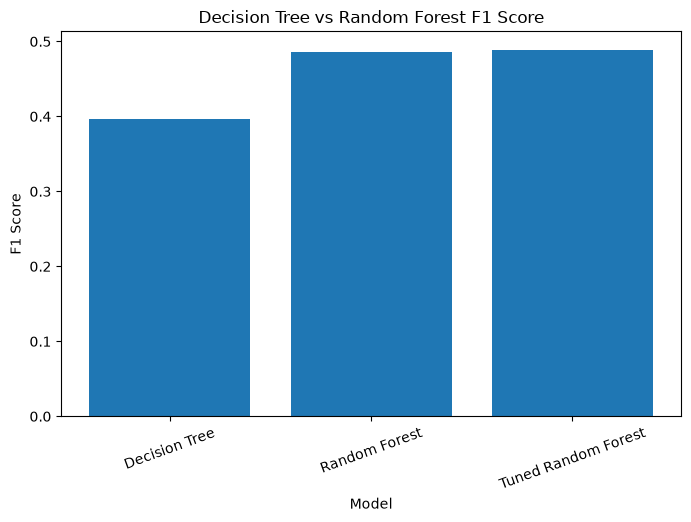

In [18]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["F1 Score"])

plt.title("Decision Tree vs Random Forest F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.xticks(rotation=20)
plt.show()

## Interpretation

The Decision Tree model provides an interpretable view of how the dataset separates high-conversion and low-conversion outcomes. However, a single tree can be sensitive to the training data and may overfit if it grows too deep. To reduce this risk, the tree depth was limited.

The Random Forest model combines many decision trees, which usually improves stability and reduces overfitting. Hyperparameter tuning was used to select the best number of trees, maximum depth, and minimum number of samples required to split a node. The feature importance chart shows which marketing variables contributed most to the prediction of conversion propensity.

## Conclusion

This notebook applied Decision Tree and Random Forest models to the Marketing Conversion Propensity dataset. The Decision Tree model was useful because it provided a simple and interpretable structure for understanding how predictor variables relate to conversion outcomes. However, because single trees can overfit the training data, a maximum depth limit was applied.

The Random Forest model extended this approach by combining multiple decision trees into an ensemble. This helped improve stability and reduce reliance on one individual tree. Hyperparameter tuning was used to identify the best combination of number of trees, tree depth, and minimum samples needed for splitting. Overall, the Random Forest model is useful for this project because it can capture nonlinear patterns and interactions among marketing variables while also providing feature importance values that support business interpretation.